# Tutorial_yolov5_voc.ipynb

## 1. Library Install& Import

In [1]:
import torch
import torchvision
from torchvision import datasets
import os
import sys
import xml.etree.ElementTree as ET
import glob
import random
import shutil
import numpy as np
import yaml
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import io
from utils import *

print("Python version :", sys.version)
print("PyTorch version :", torch.__version__)
print("Torchvision version :", torchvision.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device :", device)

epochs = 5
batch_size = 4

Python version : 3.10.16 (main, Dec 11 2024, 16:24:50) [GCC 11.2.0]
PyTorch version : 2.6.0+cu124
Torchvision version : 0.21.0+cu124
Using Device : cuda


## 2. Download Pascal VOC Dataset (torchvision)

In [2]:
from torchvision.datasets import VOCDetection

DATA_ROOT = "./"

voc_train = VOCDetection(
    root=DATA_ROOT,
    year="2007",
    image_set="train",  
    download=True,       
    transform=None,
    target_transform=None
)
print("VOC 2007 trainset download completed!")
print("Number of data:", len(voc_train), )
print("Check saved path structure:", os.listdir(os.path.join(DATA_ROOT, "VOCdevkit")))

VOC 2007 trainset download completed!
Number of data: 2501
Check saved path structure: ['VOC2007']


Annotation structure:
{'annotation': {'folder': 'VOC2007', 'filename': '000017.jpg', 'source': {'database': 'The VOC2007 Database', 'annotation': 'PASCAL VOC2007', 'image': 'flickr', 'flickrid': '228217974'}, 'owner': {'flickrid': 'genewolf', 'name': 'whiskey kitten'}, 'size': {'width': '480', 'height': '364', 'depth': '3'}, 'segmented': '0', 'object': [{'name': 'person', 'pose': 'Left', 'truncated': '0', 'difficult': '0', 'bndbox': {'xmin': '185', 'ymin': '62', 'xmax': '279', 'ymax': '199'}}, {'name': 'horse', 'pose': 'Left', 'truncated': '0', 'difficult': '0', 'bndbox': {'xmin': '90', 'ymin': '78', 'xmax': '403', 'ymax': '336'}}]}}
Image size: (480, 364)
Image filename: 000017.jpg
Image folder: VOC2007
Total objects in this image: 2


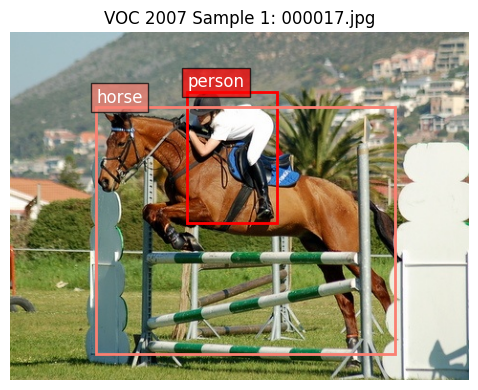

In [3]:
fig, ax = visualize_voc_sample(voc_train, 1)

## 3. Dataset configuration

In [4]:
# Function to convert VOC XML into YOLO text
# Split train/val/test 
# Create a data.yaml file
yolo_dataset = "yolo_voc_dataset"
os.makedirs(yolo_dataset, exist_ok=True)
setup_yolo_dataset(yolo_dataset)

Found 5011 valid images and labels.
Training: 3006 images (60.0%)
Validation: 1002 images (20.0%)
Testing: 1003 images (20.0%)
Created dataset.yaml in yolo_voc_dataset


## 4. Training YOLOv5 (Ultralytics)

In [5]:
from ultralytics import YOLO
# Load model
model = YOLO("yolov5s.pt")
print("YOLOv5 model loading complete!")

model.train(
    data=os.path.join(yolo_dataset, "dataset.yaml"),
    epochs=epochs,
    batch=batch_size,
    imgsz=416,
    name="yolov5_voc_demo",
    device=device,
    workers=max(1, os.cpu_count() - 1),
    verbose=False  
)
print('Train End')

PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

YOLOv5 model loading complete!
Ultralytics 8.3.96 🚀 Python-3.10.16 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24253MiB)
engine/trainer: task=detect, mode=train, model=yolov5s.pt, data=yolo_voc_dataset/dataset.yaml, epochs=5, time=None, patience=100, batch=4, imgsz=416, save=True, save_period=-1, cache=False, device=cuda, workers=31, project=None, name=yolov5_voc_demo, exist_ok=False, pretrained=True, optimizer=auto, verbose=False, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max

train: Scanning /home/sanghyuck/Desktop/LSH_74/CAU_25_Spring_ComputerVision/Week

train: New cache created: /home/sanghyuck/Desktop/LSH_74/CAU_25_Spring_ComputerVision/Week04/yolo_voc_dataset/labels/train.cache



val: Scanning /home/sanghyuck/Desktop/LSH_74/CAU_25_Spring_ComputerVision/Week04

val: New cache created: /home/sanghyuck/Desktop/LSH_74/CAU_25_Spring_ComputerVision/Week04/yolo_voc_dataset/labels/val.cache


...

        5/5     0.893G      1.039      1.272       1.21         34        416: 1
                 Class     Images  Instances      Box(P          R      mAP50  m

                   all       1002       2573      0.723      0.697      0.755      0.539



5 epochs completed in 0.025 hours.
Optimizer stripped from runs/detect/yolov5_voc_demo/weights/last.pt, 18.5MB
Optimizer stripped from runs/detect/yolov5_voc_demo/weights/best.pt, 18.5MB

Validating runs/detect/yolov5_voc_demo/weights/best.pt...
Ultralytics 8.3.96 🚀 Python-3.10.16 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24253MiB)
YOLOv5s summary (fused): 84 layers, 9,119,276 parameters, 0 gradients, 23.9 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all       1002       2573      0.723      0.696      0.756      0.539
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/detect/yolov5_voc_demo
Train End


## 5. Inference

In [19]:
from ultralytics import YOLO
# Load the best trained model
trained_model = YOLO("runs/detect/yolov5_voc_demo/weights/best.pt")

conf = 0.5
# Run inference on test dataset
print("Running inference on test dataset...")
test_results = trained_model.val(
    data=os.path.join(yolo_dataset, "dataset.yaml"),
    split="test",  # Specify test split
    imgsz=416,
    batch=batch_size,
    device=device,
    conf=conf,  # 신뢰도 임계값 설정 (0.0 ~ 1.0)
    save_json=True,  # Save results in COCO JSON format
    save_conf=True,  # Save confidence scores
    plots=True,  # Generate performance plots
    verbose=False  
)

print("\nPerformance Measures on Test Dataset:")
measures = test_results.box

print(f"mAP@0.5      : {measures.map50:.6f}")
print(f"mAP@0.5:0.95 : {measures.map:.6f}")

if isinstance(measures.p, np.ndarray):
    print(f"Precision    : {np.mean(measures.p):.6f} (mean)")
    print(f"Recall       : {np.mean(measures.r):.6f} (mean)")
    print(f"F1-Score     : {np.mean(measures.f1):.6f} (mean)")
else:
    print(f"Precision    : {measures.p:.6f}")
    print(f"Recall       : {measures.r:.6f}")
    print(f"F1-Score     : {measures.f1:.6f}")

print(f"\nDetailed results saved to: {test_results.save_dir}")

print("\nRunning inference on individual test images...")
test_image_dir = os.path.join(yolo_dataset, "images/test")
output_dir = "test_predictions"
run_individual_inference(trained_model, test_image_dir, output_dir, conf=conf)

print(f"Inference results saved to: {output_dir}")

Running inference on test dataset...
Ultralytics 8.3.96 🚀 Python-3.10.16 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24253MiB)
YOLOv5s summary (fused): 84 layers, 9,119,276 parameters, 0 gradients, 23.9 GFLOPs


val: Scanning /home/sanghyuck/Desktop/LSH_74/CAU_25_Spring_ComputerVision/Week04
                 Class     Images  Instances      Box(P          R      mAP50  m


                   all       1003       2537      0.774      0.661      0.733      0.569
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 0.2ms postprocess per image
Saving runs/detect/val8/predictions.json...
Results saved to runs/detect/val8

Performance Measures on Test Dataset:
mAP@0.5      : 0.732738
mAP@0.5:0.95 : 0.568822
Precision    : 0.774079 (mean)
Recall       : 0.660740 (mean)
F1-Score     : 0.710419 (mean)

Detailed results saved to: runs/detect/val8

Running inference on individual test images...
Inference results saved to: test_predictions


## 6. Confusion Matrix

Generating confusion matrix visualization...
Generating confusion matrix...
Normalized confusion matrix saved: test_predictions/confusion_matrix_norm.png


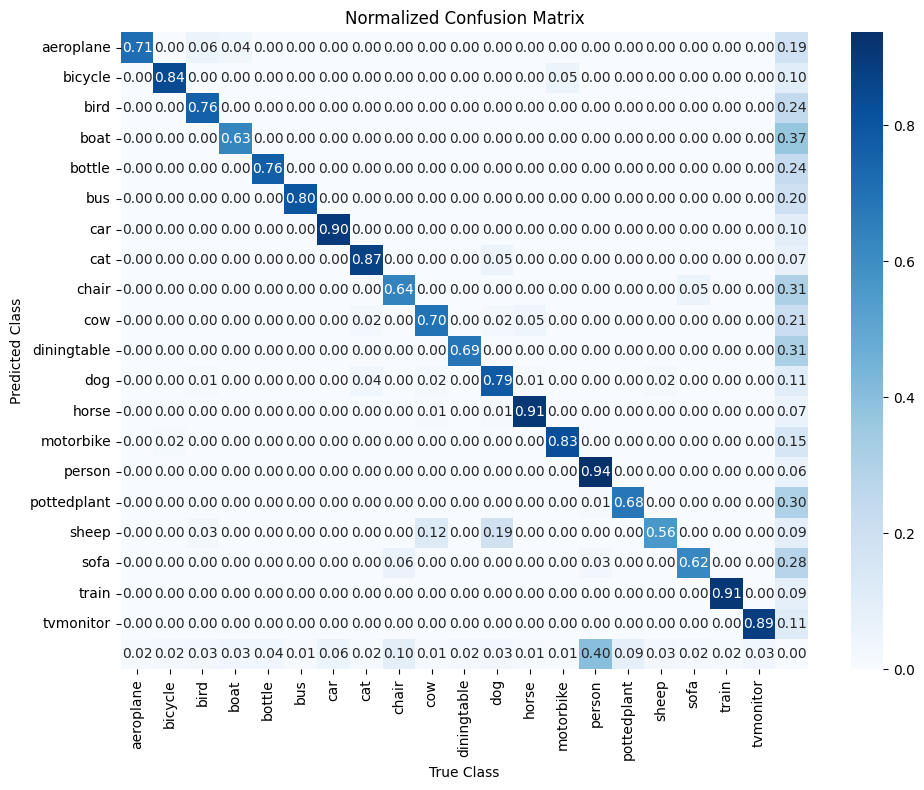

Raw confusion matrix saved: test_predictions/confusion_matrix.png


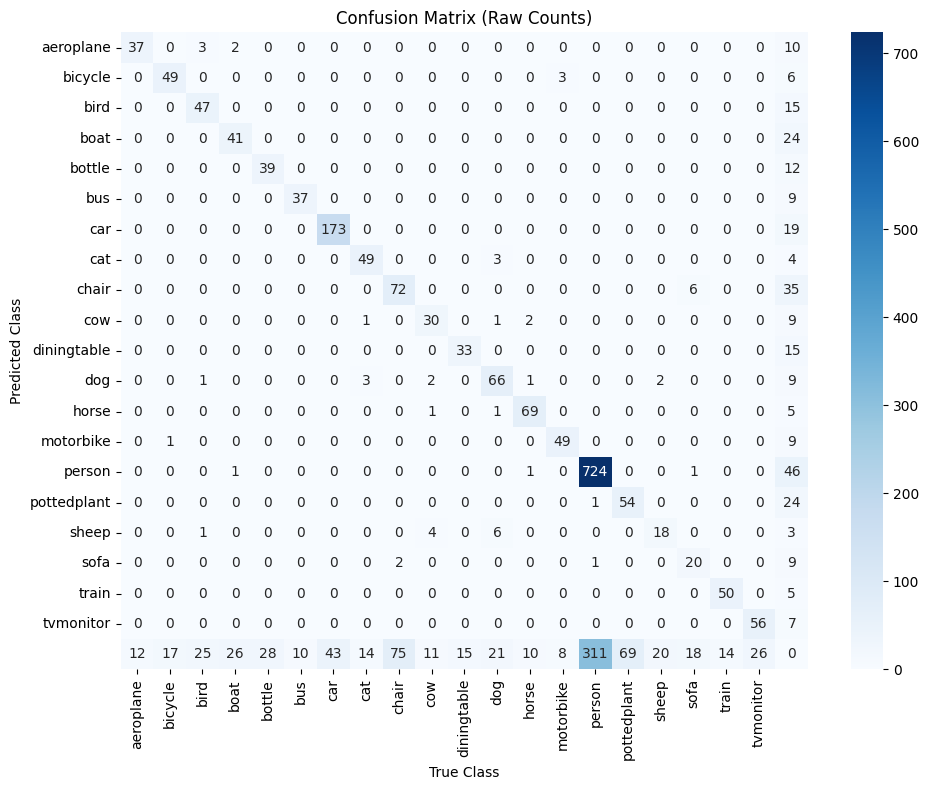


Class-wise performance metrics:
aeroplane: Precision=0.7115, Recall=0.7551
bicycle: Precision=0.8448, Recall=0.7313
bird: Precision=0.7581, Recall=0.6104
boat: Precision=0.6308, Recall=0.5857
bottle: Precision=0.7647, Recall=0.5821
bus: Precision=0.8043, Recall=0.7872
car: Precision=0.9010, Recall=0.8009
cat: Precision=0.8750, Recall=0.7313
chair: Precision=0.6372, Recall=0.4832
cow: Precision=0.6977, Recall=0.6250
diningtable: Precision=0.6875, Recall=0.6875
dog: Precision=0.7857, Recall=0.6735
horse: Precision=0.9079, Recall=0.8313
motorbike: Precision=0.8305, Recall=0.8167
person: Precision=0.9366, Recall=0.6982
pottedplant: Precision=0.6835, Recall=0.4390
sheep: Precision=0.5625, Recall=0.4500
sofa: Precision=0.6250, Recall=0.4444
train: Precision=0.9091, Recall=0.7812
tvmonitor: Precision=0.8889, Recall=0.6829
Confusion matrix visualization complete


In [20]:
# Add the following lines after your existing code
print("Generating confusion matrix visualization...")
conf_matrix, conf_matrix_norm = plot_confusion_matrix(test_results, output_dir)
print("Confusion matrix visualization complete")

## 7. Error Analysis

In [23]:
import os
import cv2
import json
import numpy as np
import shutil
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

def analyze_model_predictions(model, dataset_yaml, class_ids=None, 
                              iou_thresh=0.5, conf_thresh=0.5):
    """
    Analyze model predictions and separate True Positives and False Negatives for specified classes.
    
    Args:
        model: Trained YOLO model
        dataset_yaml: Path to dataset YAML file
        class_ids: List of class IDs to analyze (if None, analyze all classes)
        iou_thresh: IoU threshold for determining TP
        conf_thresh: Confidence threshold for predictions
    
    Returns:
        Dictionary with TP and FN analysis results
    """
    print(f"Analyzing predictions for classes: {class_ids if class_ids else 'all'}")
    
    # Load dataset info from YAML
    import yaml
    with open(dataset_yaml, 'r') as f:
        dataset_info = yaml.safe_load(f)
    
    # Get class names
    class_names = dataset_info['names']
    print(f"Class names: {class_names}")
    
    # If class_ids not specified, use all classes
    if class_ids is None:
        class_ids = list(range(len(class_names)))
    
    # Get test image paths
    test_img_dir = os.path.join(os.path.dirname(dataset_yaml), "images/test")
    test_label_dir = os.path.join(os.path.dirname(dataset_yaml), "labels/test")
    
    test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) 
                  if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    # Create output directories
    output_root = "prediction_analysis"
    os.makedirs(output_root, exist_ok=True)
    
    # Dictionary to store results
    analysis_results = {}
    
    for class_id in class_ids:
        class_name = class_names[class_id]
        print(f"\nAnalyzing class {class_id}: {class_name}")
        
        # Create class output directories
        class_dir = os.path.join(output_root, f"class_{class_id}_{class_name}")
        tp_dir = os.path.join(class_dir, "true_positives")
        fn_dir = os.path.join(class_dir, "false_negatives")
        
        os.makedirs(tp_dir, exist_ok=True)
        os.makedirs(fn_dir, exist_ok=True)
        
        # For statistics
        tp_count = 0
        fn_count = 0
        
        # Process each test image
        for img_path in tqdm(test_images, desc=f"Processing {class_name}"):
            img_filename = os.path.basename(img_path)
            img_basename = os.path.splitext(img_filename)[0]
            
            # Get corresponding label file
            label_path = os.path.join(test_label_dir, f"{img_basename}.txt")
            
            # Skip if no label file (no ground truth)
            if not os.path.exists(label_path):
                continue
            
            # Read ground truth labels
            gt_boxes = []
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        c = int(parts[0])
                        # Only consider boxes of the target class
                        if c == class_id:
                            # YOLO format: class x_center y_center width height
                            x_center, y_center, width, height = map(float, parts[1:5])
                            gt_boxes.append([x_center, y_center, width, height])
            
            # Skip if no ground truth boxes of this class
            if not gt_boxes:
                continue
            
            # Run inference
            results = model(img_path, conf=conf_thresh)[0]
            
            # Get predictions for this class
            pred_boxes = []
            for i, box in enumerate(results.boxes):
                if int(box.cls) == class_id:
                    pred_boxes.append({
                        'box': box.xyxyn[0].cpu().numpy(),  # Normalized coordinates
                        'conf': float(box.conf),
                        'matched': False
                    })
            
            # Original image for visualization
            img = cv2.imread(img_path)
            img_height, img_width = img.shape[:2]
            
            # Convert ground truth from YOLO format to xyxy format
            gt_boxes_xyxy = []
            for box in gt_boxes:
                x_center, y_center, width, height = box
                x1 = (x_center - width/2)
                y1 = (y_center - height/2)
                x2 = (x_center + width/2)
                y2 = (y_center + height/2)
                gt_boxes_xyxy.append([x1, y1, x2, y2])
            
            # Match predictions to ground truth (using IoU)
            matched_gt = [False] * len(gt_boxes_xyxy)
            
            for pred in pred_boxes:
                best_iou = 0
                best_gt_idx = -1
                
                # Convert pred box from normalized xyxy to absolute
                pred_box = pred['box']
                
                # Find best matching ground truth box
                for i, gt_box in enumerate(gt_boxes_xyxy):
                    if not matched_gt[i]:  # Only consider unmatched ground truth boxes
                        iou = calculate_iou(pred_box, gt_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = i
                
                # If IoU exceeds threshold, mark as match
                if best_iou >= iou_thresh and best_gt_idx >= 0:
                    pred['matched'] = True
                    matched_gt[best_gt_idx] = True
            
            # Create visualization image
            img_viz = img.copy()
            
            # Draw predictions (matched in green, unmatched in red)
            for pred in pred_boxes:
                box = pred['box']
                x1, y1, x2, y2 = box
                x1 = int(x1 * img_width)
                y1 = int(y1 * img_height)
                x2 = int(x2 * img_width)
                y2 = int(y2 * img_height)
                
                color = (0, 255, 0) if pred['matched'] else (0, 0, 255)  # Green if TP, Red if FP
                cv2.rectangle(img_viz, (x1, y1), (x2, y2), color, 2)
                
                # Add confidence score inside the bounding box
                conf_text = f"{pred['conf']:.2f}"
                text_size = cv2.getTextSize(conf_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]
                
                # Make a small filled rectangle for better text visibility
                cv2.rectangle(img_viz, 
                             (x1, y1), 
                             (x1 + text_size[0] + 5, y1 + text_size[1] + 5), 
                             color, -1)  # Filled rectangle
                
                # Add white text on the filled rectangle
                cv2.putText(img_viz, conf_text, (x1 + 2, y1 + text_size[1] + 2), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            
            # Draw ground truth (matched in blue, unmatched in yellow) with dashed lines
            for i, box in enumerate(gt_boxes_xyxy):
                x1, y1, x2, y2 = box
                x1 = int(x1 * img_width)
                y1 = int(y1 * img_height)
                x2 = int(x2 * img_width)
                y2 = int(y2 * img_height)
                
                color = (230, 100, 0) if matched_gt[i] else (0, 255, 255)  # Blue if matched, Yellow if FN
                
                # Create dashed line pattern for ground truth boxes
                # Draw top line (dashed)
                for x in range(x1, x2, 10):
                    end_x = min(x + 5, x2)
                    cv2.line(img_viz, (x, y1), (end_x, y1), color, 2)
                
                # Draw bottom line (dashed)
                for x in range(x1, x2, 10):
                    end_x = min(x + 5, x2)
                    cv2.line(img_viz, (x, y2), (end_x, y2), color, 2)
                
                # Draw left line (dashed)
                for y in range(y1, y2, 10):
                    end_y = min(y + 5, y2)
                    cv2.line(img_viz, (x1, y), (x1, end_y), color, 2)
                
                # Draw right line (dashed)
                for y in range(y1, y2, 10):
                    end_y = min(y + 5, y2)
                    cv2.line(img_viz, (x2, y), (x2, end_y), color, 2)
            
            # Count True Positives and False Negatives
            tp_in_image = sum(pred['matched'] for pred in pred_boxes)
            fn_in_image = sum(not m for m in matched_gt)
            
            # Save image if it has TP or FN
            if tp_in_image > 0:
                tp_count += tp_in_image
                cv2.imwrite(os.path.join(tp_dir, img_filename), img_viz)
            
            if fn_in_image > 0:
                fn_count += fn_in_image
                cv2.imwrite(os.path.join(fn_dir, img_filename), img_viz)
        
        # Save statistics
        analysis_results[class_id] = {
            'class_name': class_name,
            'true_positives': tp_count,
            'false_negatives': fn_count,
            'tp_dir': tp_dir,
            'fn_dir': fn_dir
        }
        
        print(f"Class {class_id} ({class_name}) analysis complete:")
        print(f"  - True Positives: {tp_count}")
        print(f"  - False Negatives: {fn_count}")
        print(f"  - TP images saved to: {tp_dir}")
        print(f"  - FN images saved to: {fn_dir}")
    
    # Save overall results
    with open(os.path.join(output_root, "analysis_results.json"), 'w') as f:
        json.dump({str(k): v for k, v in analysis_results.items()}, f, indent=4)
    
    return analysis_results

def calculate_iou(box1, box2):
    """
    Calculate IoU between two boxes in [x1, y1, x2, y2] format
    """
    # Box coordinates
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    
    # Calculate area of each box
    area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
    
    # Calculate coordinates of intersection
    x1_i = max(x1_1, x1_2)
    y1_i = max(y1_1, y1_2)
    x2_i = min(x2_1, x2_2)
    y2_i = min(y2_1, y2_2)
    
    # Check if boxes overlap
    if x2_i <= x1_i or y2_i <= y1_i:
        return 0.0
    
    # Calculate area of intersection
    area_i = (x2_i - x1_i) * (y2_i - y1_i)
    
    # Calculate IoU
    iou = area_i / (area1 + area2 - area_i)
    
    return iou


# Analyze specific classes (e.g., [0, 1, 2])
# Set to None to analyze all classes
class_ids = [14]  # Analyze only classes 0 and 1

# Run analysis
results = analyze_model_predictions(
    model=model,
    dataset_yaml=os.path.join(yolo_dataset, "dataset.yaml"),
    class_ids=class_ids,
    iou_thresh=0.5,
    conf_thresh=0.5
)

print("Analysis complete!")
print(f"Results saved to prediction_analysis/")

Analyzing predictions for classes: [14]
Class names: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

Analyzing class 14: person


Processing person: 100%|███████████████████| 1003/1003 [00:02<00:00, 417.99it/s]

Class 14 (person) analysis complete:
  - True Positives: 699
  - False Negatives: 338
  - TP images saved to: prediction_analysis/class_14_person/true_positives
  - FN images saved to: prediction_analysis/class_14_person/false_negatives
Analysis complete!
Results saved to prediction_analysis/
